<a href="https://colab.research.google.com/github/kridtapon/CMO-Aroon-Strategy/blob/main/CMO_Aroon_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.6/527.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.3 MB/s eta 0:00:00


In [ ]:
pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.54
    Uninstalling yfinance-0.2.54:
      Successfully uninstalled yfinance-0.2.54


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt

# Function to calculate Chande Momentum Oscillator (CMO)
def calculate_cmo(df, period=14):
    """
    Calculate Chande Momentum Oscillator (CMO).
    """
    up_moves = df['Close'].diff()
    down_moves = -df['Close'].diff()

    up_moves[up_moves < 0] = 0
    down_moves[down_moves < 0] = 0

    sum_up = up_moves.rolling(window=period).sum()
    sum_down = down_moves.rolling(window=period).sum()

    cmo = 100 * (sum_up - sum_down) / (sum_up + sum_down)
    return cmo

# Function to calculate Aroon Indicator
def calculate_aroon(df, period=14):
    """
    Calculate Aroon Indicator.
    """
    aroon_up = 100 * (df['High'].rolling(window=period).apply(lambda x: np.argmax(x) + 1) / period)
    aroon_down = 100 * (df['Low'].rolling(window=period).apply(lambda x: np.argmin(x) + 1) / period)
    return aroon_up, aroon_down

# Define the stock symbol and time period
symbol = 'META'  # SPY is the symbol for the S&P 500 ETF
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download the data
df = yf.download(symbol, start=start_date, end=end_date)
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# Calculate Chande Momentum Oscillator (CMO)
df['CMO'] = calculate_cmo(df)

# Calculate Aroon Indicator (Aroon Up and Aroon Down)
df['Aroon_Up'], df['Aroon_Down'] = calculate_aroon(df)

# Filter data for the test period (2020-2025)
df = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

# Define Entry and Exit signals based on CMO and Aroon Indicator
df['Entry'] = (df['CMO'] > 50) & (df['Aroon_Up'] > 70)
df['Exit'] = (df['CMO'] < -50) & (df['Aroon_Down'] > 70)

# Backtest using vectorbt
portfolio = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=df['Entry'],
    exits=df['Exit'],
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

# Display performance metrics
print(portfolio.stats())

# Plot equity curve
portfolio.plot().show()


[*********************100%***********************]  1 of 1 completed
<ipython-input-7-5123c17fc6bd>:51: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-7-5123c17fc6bd>:52: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Start                         2020-01-02 00:00:00
End                           2024-12-31 00:00:00
Period                         1258 days 00:00:00
Start Value                              100000.0
End Value                           188651.864134
Total Return [%]                        88.651864
Benchmark Return [%]                   180.172898
Max Gross Exposure [%]                      100.0
Total Fees Paid                        5602.16612
Max Drawdown [%]                         47.27478
Max Drawdown Duration           670 days 00:00:00
Total Trades                                   21
Total Closed Trades                            20
Total Open Trades                               1
Open Trade PnL                       -9500.453595
Win Rate [%]                                 40.0
Best Trade [%]                          53.027113
Worst Trade [%]                        -12.256327
Avg Winning Trade [%]                   21.939052
Avg Losing Trade [%]                    -6.379737


[*********************100%***********************]  1 of 1 completed


Best CMO Period: 12.0, Best Aroon Period: 7.0
Best Total Return: 2532.01%


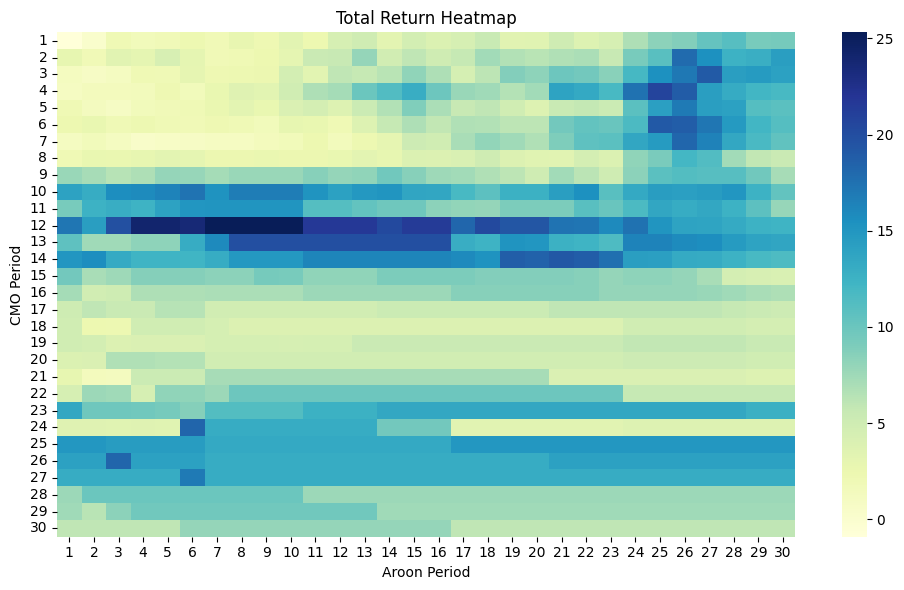

Start                         2020-01-01 00:00:00
End                           2024-12-31 00:00:00
Period                         1827 days 00:00:00
Start Value                              100000.0
End Value                          2632006.234818
Total Return [%]                      2532.006235
Benchmark Return [%]                  1197.596406
Max Gross Exposure [%]                      100.0
Total Fees Paid                      26647.340067
Max Drawdown [%]                        27.886954
Max Drawdown Duration           601 days 00:00:00
Total Trades                                   12
Total Closed Trades                            11
Total Open Trades                               1
Open Trade PnL                      737712.772996
Win Rate [%]                            63.636364
Best Trade [%]                           559.8396
Worst Trade [%]                        -11.268017
Avg Winning Trade [%]                   102.46843
Avg Losing Trade [%]                     -6.86174


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# -----------------------------
# Indicator Functions
# -----------------------------
def calculate_cmo(df, period=14):
    """
    Calculate Chande Momentum Oscillator (CMO).
    """
    up_moves = df['Close'].diff()
    down_moves = -df['Close'].diff()

    up_moves[up_moves < 0] = 0
    down_moves[down_moves < 0] = 0

    sum_up = up_moves.rolling(window=period).sum()
    sum_down = down_moves.rolling(window=period).sum()

    cmo = 100 * (sum_up - sum_down) / (sum_up + sum_down)
    return cmo

def calculate_aroon(df, period=14):
    """
    Calculate Aroon Indicator.
    """
    aroon_up = 100 * (df['High'].rolling(window=period).apply(lambda x: np.argmax(x) + 1, raw=True)) / period
    aroon_down = 100 * (df['Low'].rolling(window=period).apply(lambda x: np.argmin(x) + 1, raw=True)) / period
    return aroon_up, aroon_down

# -----------------------------
# Data Download
# -----------------------------
symbol = 'BTC-USD'
start_date = '2019-01-01'
end_date = '2025-01-01'
df = yf.download(symbol, start=start_date, end=end_date)
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# -----------------------------
# Parameter Ranges
# -----------------------------
cmo_periods = range(1, 31)
aroon_periods = range(1, 31)

results = []

# -----------------------------
# Optimization Loop
# -----------------------------
for cmo_p, aroon_p in itertools.product(cmo_periods, aroon_periods):
    # Use defined functions
    cmo = calculate_cmo(df, period=cmo_p)
    aroon_up, aroon_down = calculate_aroon(df, period=aroon_p)

    # Define entry/exit signals
    entry = (cmo > 50) & (aroon_up > 70)
    exit = (cmo < -50) & (aroon_down > 70)

    # Filter data for the test period (2020-2025)
    df_test = df[(df.index.year >= 2020) & (df.index.year <= 2025)]
    entry_test = entry[df_test.index]
    exit_test = exit[df_test.index]

    # Backtest with Vectorbt
    pf = vbt.Portfolio.from_signals(
        close=df_test['Close'],
        entries=entry_test,
        exits=exit_test,
        init_cash=100_000,
        fees=0.001,
        slippage=0.002,
        freq='D'
    )

    results.append((cmo_p, aroon_p, pf.total_return()))

# -----------------------------
# Results Analysis
# -----------------------------
results_df = pd.DataFrame(results, columns=['CMO_Period', 'Aroon_Period', 'Total_Return'])

# Pivot for heatmap
heatmap_data = results_df.pivot(index='CMO_Period', columns='Aroon_Period', values='Total_Return')

# Find best combo
best_row = results_df.loc[results_df['Total_Return'].idxmax()]
print(f"Best CMO Period: {best_row['CMO_Period']}, Best Aroon Period: {best_row['Aroon_Period']}")
print(f"Best Total Return: {best_row['Total_Return']:.2%}")

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Total Return Heatmap")
plt.xlabel("Aroon Period")
plt.ylabel("CMO Period")
plt.tight_layout()
plt.show()

# -----------------------------
# Plot Best Portfolio
# -----------------------------
best_cmo = int(best_row['CMO_Period'])
best_aroon = int(best_row['Aroon_Period'])

cmo = calculate_cmo(df, period=best_cmo)
aroon_up, aroon_down = calculate_aroon(df, period=best_aroon)

entry = (cmo > 50) & (aroon_up > 70)
exit = (cmo < -50) & (aroon_down > 70)

# Filter data for the test period (2020-2025)
df_test = df[(df.index.year >= 2020) & (df.index.year <= 2025)]
entry_test = entry[df_test.index]
exit_test = exit[df_test.index]

best_pf = vbt.Portfolio.from_signals(
    close=df_test['Close'],
    entries=entry_test,
    exits=exit_test,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

best_pf.plot().show()
print(best_pf.stats())

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Download data
symbol = 'META'
start_date = '2019-01-01'
end_date = '2025-01-01'
df = yf.download(symbol, start=start_date, end=end_date)
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# Define parameter ranges
cmo_periods = range(1, 201)
aroon_periods = range(1, 201)

# Store results
results = []

# Loop through all parameter combinations
for cmo_p, aroon_p in itertools.product(cmo_periods, aroon_periods):
    # Calculate CMO
    up_moves = df['Close'].diff().clip(lower=0)
    down_moves = -df['Close'].diff().clip(upper=0)
    sum_up = up_moves.rolling(window=cmo_p).sum()
    sum_down = down_moves.rolling(window=cmo_p).sum()
    cmo = 100 * (sum_up - sum_down) / (sum_up + sum_down)

    # Calculate Aroon
    aroon_up = 100 * df['High'].rolling(aroon_p).apply(lambda x: np.argmax(x) + 1, raw=True) / aroon_p
    aroon_down = 100 * df['Low'].rolling(aroon_p).apply(lambda x: np.argmin(x) + 1, raw=True) / aroon_p

    # Define signals
    entry = (cmo > 50) & (aroon_up > 70)
    exit = (cmo < -50) & (aroon_down > 70)

    # Backtest
    pf = vbt.Portfolio.from_signals(
        close=df['Close'],
        entries=entry,
        exits=exit,
        init_cash=100_000,
        fees=0.001,
        slippage=0.002,
        freq='D'
    )

    # Save result
    total_return = pf.total_return()
    results.append((cmo_p, aroon_p, total_return))

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['CMO_Period', 'Aroon_Period', 'Total_Return'])

# Pivot for heatmap
heatmap_data = results_df.pivot(index='CMO_Period', columns='Aroon_Period', values='Total_Return')

# Find best parameters
best_row = results_df.loc[results_df['Total_Return'].idxmax()]
print(f"Best CMO Period: {best_row['CMO_Period']}, Best Aroon Period: {best_row['Aroon_Period']}")
print(f"Best Total Return: {best_row['Total_Return']:.2%}")

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2%", cmap="YlGnBu")
plt.title("Total Return Heatmap")
plt.xlabel("Aroon Period")
plt.ylabel("CMO Period")
plt.tight_layout()
plt.show()

# Optional: Plot best portfolio
# Re-calculate signals for best params
best_cmo = int(best_row['CMO_Period'])
best_aroon = int(best_row['Aroon_Period'])

up_moves = df['Close'].diff().clip(lower=0)
down_moves = -df['Close'].diff().clip(upper=0)
sum_up = up_moves.rolling(window=best_cmo).sum()
sum_down = down_moves.rolling(window=best_cmo).sum()
cmo = 100 * (sum_up - sum_down) / (sum_up + sum_down)

aroon_up = 100 * df['High'].rolling(best_aroon).apply(lambda x: np.argmax(x) + 1, raw=True) / best_aroon
aroon_down = 100 * df['Low'].rolling(best_aroon).apply(lambda x: np.argmin(x) + 1, raw=True) / best_aroon

entry = (cmo > 50) & (aroon_up > 70)
exit = (cmo < -50) & (aroon_down > 70)

best_pf = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=entry,
    exits=exit,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

best_pf.plot().show()


[*********************100%***********************]  1 of 1 completed


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 23 with shape (1258,) and arg 31 with shape (1510,).

[*********************100%***********************]  1 of 1 completed


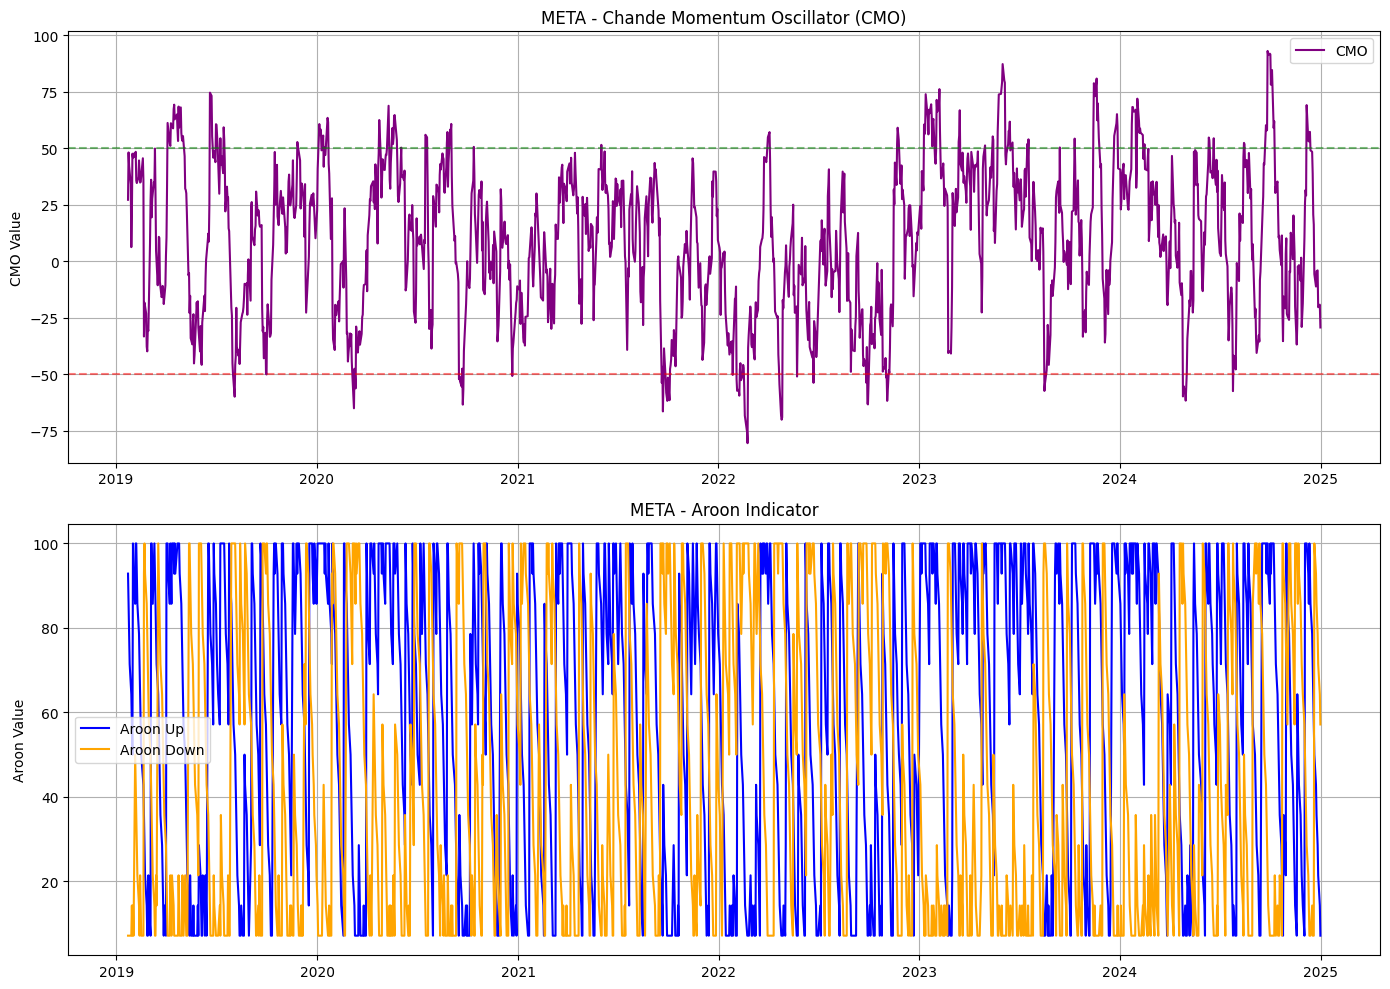

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Function to calculate Chande Momentum Oscillator (CMO)
def calculate_cmo(df, period=14):
    up_moves = df['Close'].diff()
    down_moves = -df['Close'].diff()

    up_moves[up_moves < 0] = 0
    down_moves[down_moves < 0] = 0

    sum_up = up_moves.rolling(window=period).sum()
    sum_down = down_moves.rolling(window=period).sum()

    cmo = 100 * (sum_up - sum_down) / (sum_up + sum_down)
    return cmo

# Function to calculate Aroon Indicator
def calculate_aroon(df, period=14):
    aroon_up = 100 * (df['High'].rolling(window=period).apply(lambda x: np.argmax(x) + 1) / period)
    aroon_down = 100 * (df['Low'].rolling(window=period).apply(lambda x: np.argmin(x) + 1) / period)
    return aroon_up, aroon_down

# Define the stock symbol and time period
symbol = 'META'
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download the data
df = yf.download(symbol, start=start_date, end=end_date)
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# Calculate indicators
df['CMO'] = calculate_cmo(df)
df['Aroon_Up'], df['Aroon_Down'] = calculate_aroon(df)

# Plotting
plt.figure(figsize=(14, 10))

# Plot CMO
plt.subplot(2, 1, 1)
plt.plot(df.index, df['CMO'], label='CMO', color='purple')
plt.axhline(50, color='green', linestyle='--', alpha=0.5)
plt.axhline(-50, color='red', linestyle='--', alpha=0.5)
plt.title(f'{symbol} - Chande Momentum Oscillator (CMO)')
plt.ylabel('CMO Value')
plt.legend()
plt.grid(True)

# Plot Aroon
plt.subplot(2, 1, 2)
plt.plot(df.index, df['Aroon_Up'], label='Aroon Up', color='blue')
plt.plot(df.index, df['Aroon_Down'], label='Aroon Down', color='orange')
plt.title(f'{symbol} - Aroon Indicator')
plt.ylabel('Aroon Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed


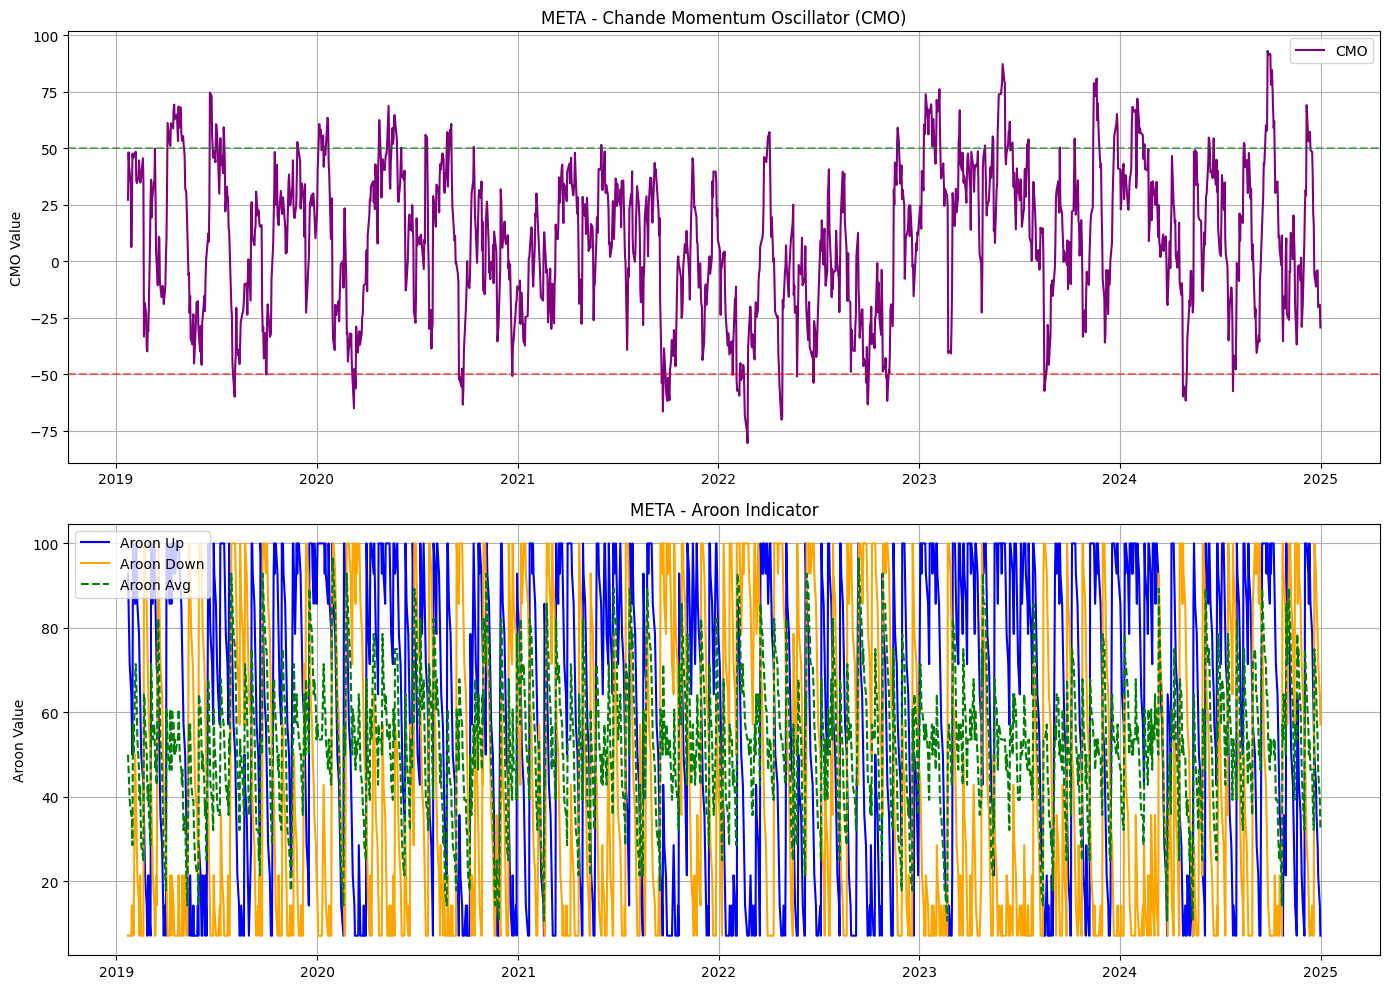

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Function to calculate Chande Momentum Oscillator (CMO)
def calculate_cmo(df, period=14):
    up_moves = df['Close'].diff()
    down_moves = -df['Close'].diff()

    up_moves[up_moves < 0] = 0
    down_moves[down_moves < 0] = 0

    sum_up = up_moves.rolling(window=period).sum()
    sum_down = down_moves.rolling(window=period).sum()

    cmo = 100 * (sum_up - sum_down) / (sum_up + sum_down)
    return cmo

# Function to calculate Aroon Indicator and Aroon Average
def calculate_aroon(df, period=14):
    aroon_up = 100 * (df['High'].rolling(window=period).apply(lambda x: np.argmax(x) + 1) / period)
    aroon_down = 100 * (df['Low'].rolling(window=period).apply(lambda x: np.argmin(x) + 1) / period)
    aroon_avg = (aroon_up + aroon_down) / 2
    return aroon_up, aroon_down, aroon_avg

# Define the stock symbol and time period
symbol = 'META'
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download the data
df = yf.download(symbol, start=start_date, end=end_date)

# Calculate indicators
df['CMO'] = calculate_cmo(df)
df['Aroon_Up'], df['Aroon_Down'], df['Aroon_Avg'] = calculate_aroon(df)

# Plotting
plt.figure(figsize=(14, 10))

# Plot CMO
plt.subplot(2, 1, 1)
plt.plot(df.index, df['CMO'], label='CMO', color='purple')
plt.axhline(50, color='green', linestyle='--', alpha=0.5)
plt.axhline(-50, color='red', linestyle='--', alpha=0.5)
plt.title(f'{symbol} - Chande Momentum Oscillator (CMO)')
plt.ylabel('CMO Value')
plt.legend()
plt.grid(True)

# Plot Aroon Indicators
plt.subplot(2, 1, 2)
plt.plot(df.index, df['Aroon_Up'], label='Aroon Up', color='blue')
plt.plot(df.index, df['Aroon_Down'], label='Aroon Down', color='orange')
plt.plot(df.index, df['Aroon_Avg'], label='Aroon Avg', color='green', linestyle='--')
plt.title(f'{symbol} - Aroon Indicator')
plt.ylabel('Aroon Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
